In [28]:
import time

start = time.time()

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

end = time.time()

print(f"Import time: {str(end - start)}")

Import time: 0.0003733634948730469


## Задание 1
Изобразить гистограмму, которая показывает баланс классов. Сделать выводы.

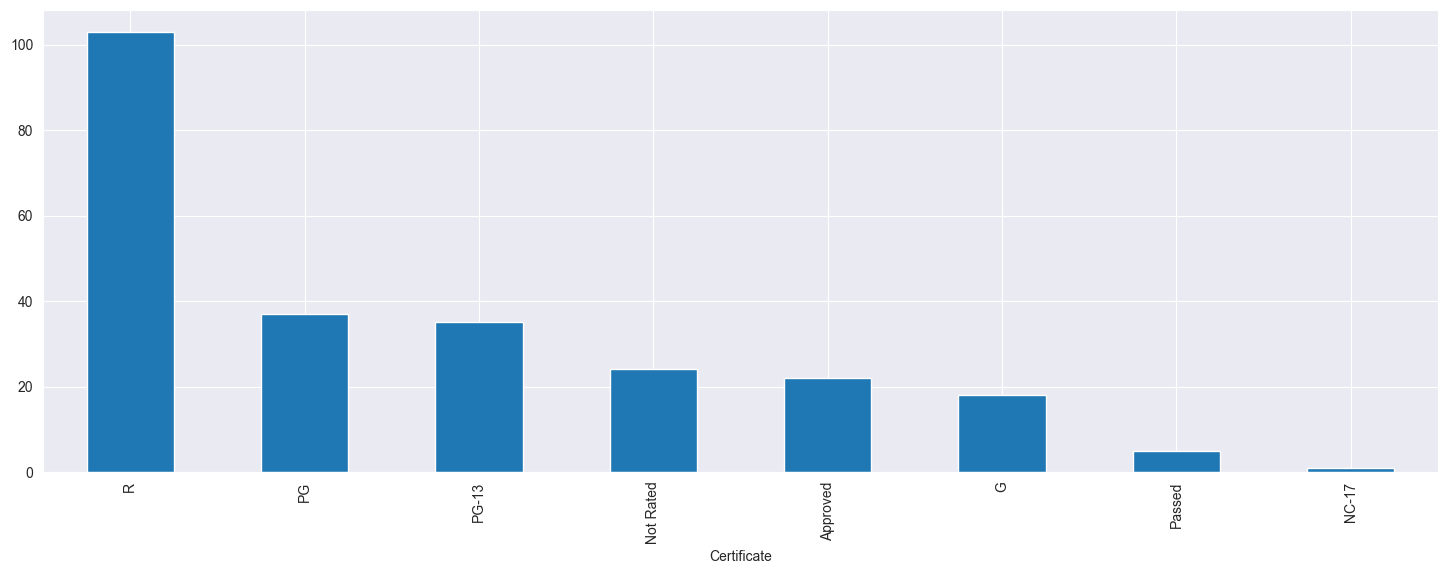

In [9]:
data = pd.read_csv('PR5/imdb_top_movies.csv', sep=',')

plt.figure(figsize=(18, 6))
data['Certificate'].value_counts().plot(kind='bar')
plt.show()

## Задание 2
Разбить выборку на тренировочную и тестовую. Тренировочная для обучения модели, тестовая для проверки ее качества.

In [21]:
data = pd.read_csv('PR5/imdb_top_movies.csv', sep=',')

print("Столбцы в датасете:", data.columns.tolist())

predictors = data.drop(columns=["Certificate"])

target = data["Certificate"]

x_train, x_test, y_train, y_test = train_test_split(
    predictors,
    target,
    train_size=0.8,
    shuffle=True,
    random_state=271
)

print("Размер для признаков обучающей выборки:", x_train.shape, '\n',
      "Размер для признаков тестовой выборки:", x_test.shape, '\n',
      "Размер для целевого показателя обучающей выборки:", y_train.shape, '\n',
      "Размер для показателя тестовой выборки:", y_test.shape)

Столбцы в датасете: ['Rank', 'Title', 'Year', 'Rating', 'Duration', 'Certificate', 'Genres', 'Description', 'Image URL', 'Movie URL']
Размер для признаков обучающей выборки: (200, 9) 
 Размер для признаков тестовой выборки: (50, 9) 
 Размер для целевого показателя обучающей выборки: (200,) 
 Размер для показателя тестовой выборки: (50,)


## Задание 3
Применить алгоритмы классификации: логистическая регрессия, SVM, KNN. Построить матрицу ошибок по результатам работы моделей (использовать confusion_matrix из sklearn.metrics).

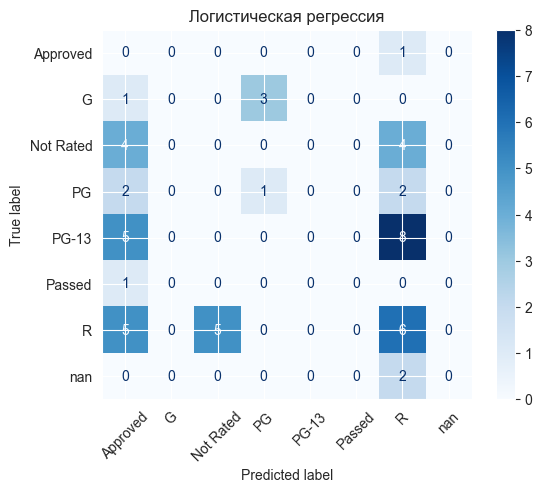

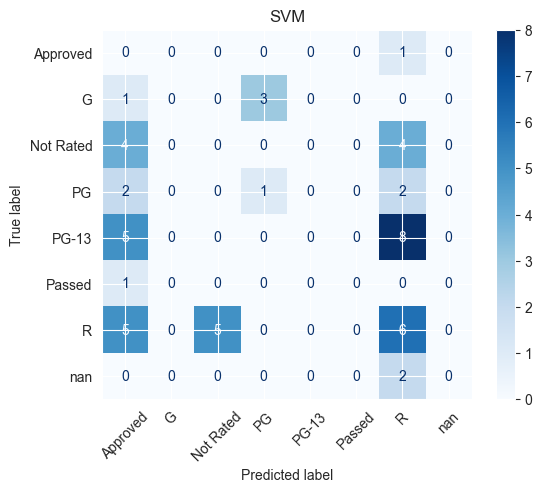

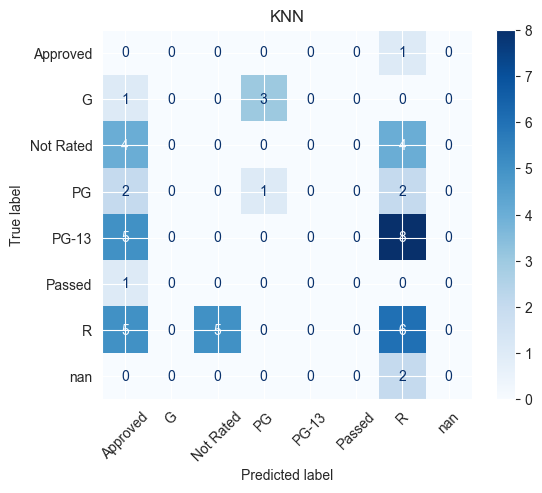

In [31]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

models = {
    "Логистическая регрессия": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)

    unique_labels = np.unique(np.concatenate((y_test, y_pred)))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.inverse_transform(unique_labels))
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"{name}")
    plt.show()


## Задание 4
Сравнить результаты классификации, используя accuracy, precision, recall и f1-меру (можно использовать classification_report из sklearn.metrics). Сделать выводы.